<a href="https://colab.research.google.com/github/hyunyoungDA/Algorithm/blob/main/ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import glob


# 클래스 이름 순서대로 설정
class_order = ['0.Good', '1.Mild', '2.Moderate', '3.Severe']

# 훈련 데이터 각 클래스의 샘플 개수 확인
print("훈련 데이터 샘플 개수:")
for class_name in class_order:
    class_path = os.path.join(train_path, class_name)
    if os.path.isdir(class_path): # 만약 class_path 경로에 파일이 존재하면?
        class_samples = len(glob.glob(os.path.join(class_path, "*.jpg"))) # class_path내의 모든 jpg를 하나로.
        print(f"{class_name} 클래스: {class_samples}개의 샘플")

# 검증 데이터 각 클래스의 샘플 개수 확인
print("\n검증 데이터 샘플 개수:")
for class_name in class_order:
    class_path = os.path.join(validation_path, class_name)
    if os.path.isdir(class_path):
        class_samples = len(glob.glob(os.path.join(class_path, "*.jpg")))
        print(f"{class_name} 클래스: {class_samples}개의 샘플")


훈련 데이터 샘플 개수:
0.Good 클래스: 534개의 샘플
1.Mild 클래스: 13346개의 샘플
2.Moderate 클래스: 3797개의 샘플
3.Severe 클래스: 836개의 샘플

검증 데이터 샘플 개수:
0.Good 클래스: 152개의 샘플
1.Mild 클래스: 3813개의 샘플
2.Moderate 클래스: 1084개의 샘플
3.Severe 클래스: 239개의 샘플


In [ ]:
import os
# 생성할 폴더 경로
model_path = '/content/model'
train_path = '/content/model/Training'
validation_path = '/content/model/Validation'

# 폴더 생성
os.makedirs(model_path, exist_ok=True)
os.makedirs(train_path, exist_ok=True)
os.makedirs(validation_path, exist_ok=True)

print("폴더 생성 완료")

폴더 생성 완료


In [ ]:
!unzip -qq '/content/drive/MyDrive/model/Training/0.양호.zip' -d '/content/model/Training/0.Good/'
!unzip -qq '/content/drive/MyDrive/model/Training/1.경증.zip' -d '/content/model/Training/1.Mild/'
!unzip -qq '/content/drive/MyDrive/model/Training/2.중등도.zip' -d '/content/model/Training/2.Moderate/'
!unzip -qq '/content/drive/MyDrive/model/Training/3.중증.zip' -d '/content/model/Training/3.Severe/'

!unzip -qq '/content/drive/MyDrive/model/Validation/0.양호.zip' -d '/content/model/Validation/0.Good/'
!unzip -qq '/content/drive/MyDrive/model/Validation/1.경증.zip' -d '/content/model/Validation/1.Mild/'
!unzip -qq '/content/drive/MyDrive/model/Validation/2.중등도.zip' -d '/content/model/Validation/2.Moderate/'
!unzip -qq '/content/drive/MyDrive/model/Validation/3.중증.zip' -d '/content/model/Validation/3.Severe/'

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
import numpy as np

In [ ]:
# 데이터셋 경로 설정
train_path = '/content/model/Training'
validation_path = '/content/model/Validation'
model_save_path = '/content/drive/MyDrive/model/best_model.keras'  # 모델 저장 경로

In [ ]:
# 이미지 크기 및 배치 크기 설정
image_size = (224,224)
batch_size = 32
random_seed = 100
epochs = 10

In [ ]:
#훈련 데이터 증강
train_datagen = ImageDataGenerator(
    rescale=1./255,  # 정규화
    rotation_range=30,  # 회전
    zoom_range=0.2,  # 확대/축소
    horizontal_flip=True, #좌우반전
    vertical_flip=True, #상하반전
    brightness_range= [0.1, 0.9], #밝기조절
    fill_mode='reflect', #회전시 생긴 공간을 채우는 방식
)
val_datagen = ImageDataGenerator(rescale=1./255)

# 데이터셋 로드
train_ds = train_datagen.flow_from_directory(
    train_path,
    target_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=random_seed,
    class_mode='sparse'
)
val_ds = val_datagen.flow_from_directory(
    validation_path,
    target_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=random_seed,
    class_mode='sparse'
)

train_ds.class_indices

Found 18513 images belonging to 4 classes.
Found 5288 images belonging to 4 classes.


{'0.Good': 0, '1.Mild': 1, '2.Moderate': 2, '3.Severe': 3}

In [ ]:
# 데이터 분포 확인
train_class_counts = train_ds.classes
valid_class_counts = val_ds.classes

# 클래스별 샘플 수 계산
train_class_distribution = {k: sum(train_class_counts == v) for k, v in train_ds.class_indices.items()}
valid_class_distribution = {k: sum(valid_class_counts == v) for k, v in val_ds.class_indices.items()}

print("훈련 데이터 클래스 분포:", train_class_distribution)
print("검증 데이터 클래스 분포:", valid_class_distribution)


훈련 데이터 클래스 분포: {'0.Good': 534, '1.Mild': 13346, '2.Moderate': 3797, '3.Severe': 836}
검증 데이터 클래스 분포: {'0.Good': 152, '1.Mild': 3813, '2.Moderate': 1084, '3.Severe': 239}


In [ ]:
print(f"Train batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")

Train batches: 579
Validation batches: 166


In [ ]:
train_samples = len(train_ds) * train_ds.batch_size
val_samples = len(val_ds) * val_ds.batch_size

print(f"Total training samples: {train_samples}")
print(f"Total validation samples: {val_samples}")

Total training samples: 18528
Total validation samples: 5312


In [ ]:
sample_batch, sample_labels = next(iter(train_ds))

# 샘플 배치의 형상 출력
print(f"샘플 배치의 특성: {sample_batch.shape}")
print(f"레이블의 특성: {sample_labels.shape}")

샘플 배치의 특성: (32, 224, 224, 3)
레이블의 특성: (32,)


In [ ]:
# 모델 구성
## Transfer learning & fine tuning
## include_top = False -> 가장 상위 계층은 loading X
base_model = ResNet50(input_shape=(image_size[0], image_size[1], 3), include_top=False, weights='imagenet')

model = models.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D()) ## 결과를 하나의 값으로 GlobalavgPooling
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(len(train_ds.class_indices), activation='softmax'))


model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5, ## epoch이 5번 째까지 성능이 나아지지 않으면 stop
    restore_best_weights=True
)

## model_save_path에 checkpoint 생성해서 가장 좋은 model을 계속 저장
model_checkpoint = ModelCheckpoint(
    model_save_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


class_counts = np.bincount(train_ds.classes)
total_samples = sum(class_counts)


class_weights = {i: total_samples / (len(class_counts) * count) for i, count in enumerate(class_counts)}


history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs = epochs,
                    class_weight=class_weights,
                    callbacks=[early_stopping, model_checkpoint, reduce_lr])



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 24,060,164 (91.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.3326 - loss: 1.2447
Epoch 1: val_loss improved from inf to 4.43513, saving model to /content/drive/MyDrive/model/best_model.keras
579/579 ━━━━━━━━━━━━━━━━━━━━ 616s 943ms/step - accuracy: 0.3327 - loss: 1.2444 - val_accuracy: 0.0465 - val_loss: 4.4351 - learning_rate: 1.0000e-05
Epoch 2/10
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 750ms/step - accuracy: 0.5074 - loss: 0.8888
Epoch 2: val_loss improved from 4.43513 to 0.95488, saving model to /content/drive/MyDrive/model/best_model.keras
579/579 ━━━━━━━━━━━━━━━━━━━━ 525s 897ms/step - accuracy: 0.5074 - loss: 0.8888 - val_accuracy: 0.5548 - val_loss: 0.9549 - learning_rate: 1.0000e-05
Epoch 3/10
579/579 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - accuracy: 0.5477 - loss: 0.8481
Epoch 3: val_loss did not improve from 0.95488
579/579 ━━━━━━━━━━━━━━━━━━━━ 477s 818ms/step - accuracy: 0.5477 - loss: 0.8481 - val_accuracy: 0.5348 - val_loss: 1.0638 - learning_rate: 1.0000e-05
Epoch 4/10
579/579 ━━━━━━━━━━

In [ ]:
# 에포크마다 손실과 정확도 출력 함수
def print_accuracy_loss(history):
    for epoch in range(len(history.history['loss'])):
        train_loss = history.history['loss'][epoch]
        val_loss = history.history['val_loss'][epoch]
        train_accuracy = history.history['accuracy'][epoch]
        val_accuracy = history.history['val_accuracy'][epoch]

        print(f"Epoch {epoch + 1}:")
        print(f"  Training Loss: {train_loss:.4f}")
        print(f"  Validation Loss: {val_loss:.4f}")
        print(f"  Training Accuracy: {train_accuracy:.4f}")
        print(f"  Validation Accuracy: {val_accuracy:.4f}")
        print("-" * 30)

# 손실과 정확도 출력
print_accuracy_loss(history)


Epoch 1:
  Training Loss: 1.0871
  Validation Loss: 4.4351
  Training Accuracy: 0.4046
  Validation Accuracy: 0.0465
------------------------------
Epoch 2:
  Training Loss: 0.8902
  Validation Loss: 0.9549
  Training Accuracy: 0.5124
  Validation Accuracy: 0.5548
------------------------------
Epoch 3:
  Training Loss: 0.8399
  Validation Loss: 1.0638
  Training Accuracy: 0.5517
  Validation Accuracy: 0.5348
------------------------------
Epoch 4:
  Training Loss: 0.8019
  Validation Loss: 0.8801
  Training Accuracy: 0.5708
  Validation Accuracy: 0.6292
------------------------------
Epoch 5:
  Training Loss: 0.7559
  Validation Loss: 0.7573
  Training Accuracy: 0.6002
  Validation Accuracy: 0.6719
------------------------------
Epoch 6:
  Training Loss: 0.7410
  Validation Loss: 0.8017
  Training Accuracy: 0.6097
  Validation Accuracy: 0.6783
------------------------------
Epoch 7:
  Training Loss: 0.7180
  Validation Loss: 0.9893
  Training Accuracy: 0.6289
  Validation Accuracy: 0.

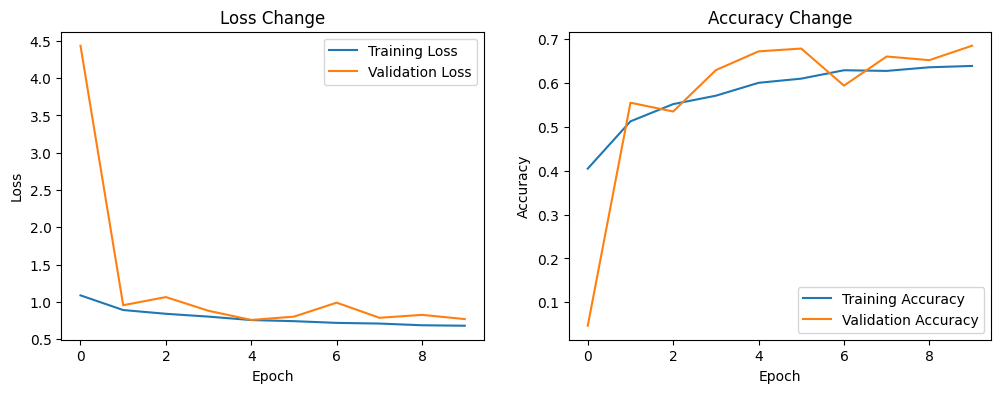

Epoch 1:
  Training Loss: 1.0871
  Validation Loss: 4.4351
  Training Accuracy: 0.4046
  Validation Accuracy: 0.0465
------------------------------
Epoch 2:
  Training Loss: 0.8902
  Validation Loss: 0.9549
  Training Accuracy: 0.5124
  Validation Accuracy: 0.5548
------------------------------
Epoch 3:
  Training Loss: 0.8399
  Validation Loss: 1.0638
  Training Accuracy: 0.5517
  Validation Accuracy: 0.5348
------------------------------
Epoch 4:
  Training Loss: 0.8019
  Validation Loss: 0.8801
  Training Accuracy: 0.5708
  Validation Accuracy: 0.6292
------------------------------
Epoch 5:
  Training Loss: 0.7559
  Validation Loss: 0.7573
  Training Accuracy: 0.6002
  Validation Accuracy: 0.6719
------------------------------
Epoch 6:
  Training Loss: 0.7410
  Validation Loss: 0.8017
  Training Accuracy: 0.6097
  Validation Accuracy: 0.6783
------------------------------
Epoch 7:
  Training Loss: 0.7180
  Validation Loss: 0.9893
  Training Accuracy: 0.6289
  Validation Accuracy: 0.

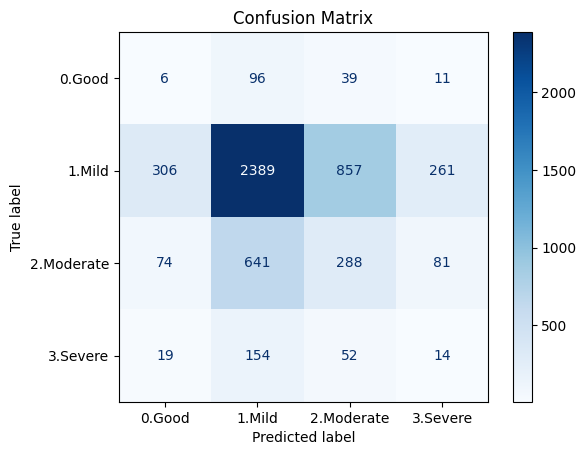

Precision: 0.5751
Recall: 0.5100
F1 Score: 0.5393


In [ ]:
# 손실과 정확도 그래프 시각화 함수
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # 손실 그래프
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Change')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # 정확도 그래프
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Change')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()
# 에포크마다 손실과 정확도 출력 함수
def print_accuracy_loss(history):
    for epoch in range(len(history.history['loss'])):
        train_loss = history.history['loss'][epoch]
        val_loss = history.history['val_loss'][epoch]
        train_accuracy = history.history['accuracy'][epoch]
        val_accuracy = history.history['val_accuracy'][epoch]

        print(f"Epoch {epoch + 1}:")
        print(f"  Training Loss: {train_loss:.4f}")
        print(f"  Validation Loss: {val_loss:.4f}")
        print(f"  Training Accuracy: {train_accuracy:.4f}")
        print(f"  Validation Accuracy: {val_accuracy:.4f}")
        print("-" * 30)

# 그래프 시각화
plot_history(history)

# 손실과 정확도 출력
print_accuracy_loss(history)

# 예측 결과 생성
y_true = val_ds.classes  # 실제 레이블
y_pred = model.predict(val_ds)  # 예측
y_pred_classes = np.argmax(y_pred, axis=1)  # 예측 클래스

# 혼동 행렬 계산
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# 혼동 행렬 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=val_ds.class_indices)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# 정밀도, 재현율, F1 점수 계산
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')


166/166 ━━━━━━━━━━━━━━━━━━━━ 31s 189ms/step


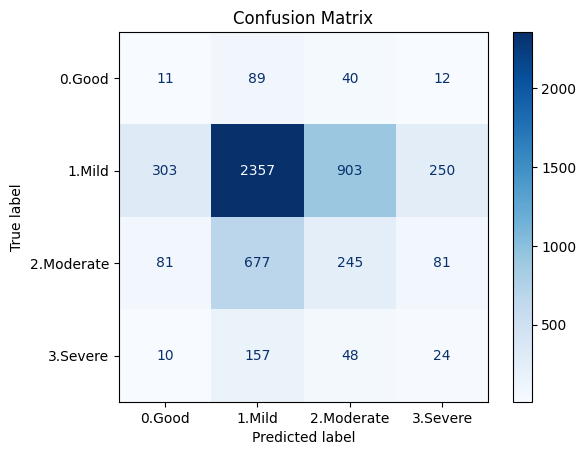

In [ ]:
# 예측 결과 생성
y_true = val_ds.classes  # 실제 레이블
y_pred = model.predict(val_ds)
y_pred_classes = np.argmax(y_pred, axis=1)  # 예측 클래스

# 혼동 행렬 계산
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# 혼동 행렬 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=val_ds.class_indices)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()